In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
import math
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
pd.set_option('display.max_columns', None)
plt.rcParams["figure.figsize"] = (15, 8)

## Load Data Set

In [136]:

username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "48-hour-exam/group_3_faa_data_subset/group_3_faa_data_subset/faa_data_subset.xlsx"

github_url = f"https://raw.githubusercontent.com/{username}/{repository}/master/{directory}"
df = pd.read_excel(github_url)


## Basic Data Inspection and Cleaning

In [137]:
#Checking the columns in the dataframe
df.columns

Index(['Airport: Code', 'Airport: Name', 'Origin State', 'Origin State Code',
       'Country', 'Aircraft: Type', 'Aircraft: Number of engines',
       'Collision Date and Time', 'When: Time of day', 'When: Phase of flight',
       'Effect: Amount of damage (detailed)', 'Effect: Impact to flight',
       'Effect: Indicated Damage',
       'Cost: Aircraft time out of service (hours)', 'Cost: Total $', 'Days',
       'Feet above ground', 'Miles from airport', 'Wildlife: Animal Category',
       'Wildlife: Species Order', 'Wildlife: Species Group',
       'Wildlife: Species', 'Wildlife: Species ID', 'Number of Strikes',
       'Record ID'],
      dtype='object')

In [138]:
# Display the shape of the dataframe
df.shape

(28298, 25)

In [139]:
# Display the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28298 entries, 0 to 28297
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Airport: Code                               28298 non-null  object        
 1   Airport: Name                               28298 non-null  object        
 2   Origin State                                28298 non-null  object        
 3   Origin State Code                           28298 non-null  object        
 4   Country                                     28298 non-null  object        
 5   Aircraft: Type                              27467 non-null  object        
 6   Aircraft: Number of engines                 25918 non-null  float64       
 7   Collision Date and Time                     28298 non-null  datetime64[ns]
 8   When: Time of day                           27655 non-null  object        
 9   When: 

In [140]:
# Understanding the shape of the data.
print('Total rows:',df.shape[0])
print('Total columns:',df.shape[1])

Total rows: 28298
Total columns: 25


In [141]:
# Display the first few rows of the dataframe
df.head()

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,Aircraft: Number of engines,Collision Date and Time,When: Time of day,When: Phase of flight,Effect: Amount of damage (detailed),Effect: Impact to flight,Effect: Indicated Damage,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID,Number of Strikes,Record ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,NaN,NaN,No damage,NaN,0,NaN,0.0,NaN,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12,1,17459
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,NaN,NaN,No damage,NaN,0,NaN,NaN,NaN,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1,1,17114
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,Medium,Aborted Take-off,Caused damage,720.0,171132,30.000,0.0,0.0,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114,1,259361
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,NaN,NaN,No damage,15.0,600,0.625,NaN,NaN,Birds,Pigeons and Doves,Doves,Mourning dove,O2205,1,345167
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Medium,NaN,Caused damage,12.0,188245,0.500,NaN,0.0,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302,1,262782


In [142]:
# Checking the categorical columns
df.select_dtypes(include=object).head()

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,When: Time of day,When: Phase of flight,Effect: Amount of damage (detailed),Effect: Impact to flight,Effect: Indicated Damage,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,Take-off run,NaN,NaN,No damage,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,NaN,Take-off run,NaN,NaN,No damage,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Day,Take-off run,Medium,Aborted Take-off,Caused damage,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Night,Approach,NaN,NaN,No damage,Birds,Pigeons and Doves,Doves,Mourning dove,O2205
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Day,Approach,Medium,NaN,Caused damage,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302


In [143]:
# Checking the numerical columns
df.select_dtypes(include=np.number).head()

,Aircraft: Number of engines,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Number of Strikes,Record ID
0,NaN,NaN,0,NaN,0.0,NaN,1,17459
1,1.0,NaN,0,NaN,NaN,NaN,1,17114
2,2.0,720.0,171132,30.000,0.0,0.0,1,259361
3,2.0,15.0,600,0.625,NaN,NaN,1,345167
4,2.0,12.0,188245,0.500,NaN,0.0,1,262782


In [144]:
# Display the summary statistics of the dataframe
df.describe().round(0)

,Aircraft: Number of engines,Collision Date and Time,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Number of Strikes,Record ID
count,25918.0,28298,2929.0,28298.0,2929.0,24872.0,19807.0,28298.0,28298.0
mean,2.0,2009-08-02 02:55:58.905929728,85.0,11385.0,4.0,339.0,0.0,1.0,271474.0
min,1.0,2000-01-02 10:27:00,0.0,0.0,0.0,0.0,0.0,1.0,1164.0
25%,2.0,2006-07-21 11:55:00,1.0,0.0,0.0,0.0,0.0,1.0,235364.0
50%,2.0,2010-07-17 07:42:00,2.0,0.0,0.0,0.0,0.0,1.0,301697.0
75%,2.0,2013-01-27 07:36:15,24.0,0.0,1.0,100.0,0.0,1.0,330425.0
max,4.0,2015-05-31 21:47:00,21000.0,41071585.0,875.0,20000.0,100.0,1.0,360842.0
std,0.0,NaN,509.0,312536.0,21.0,1065.0,3.0,0.0,81859.0


In [145]:
# display missing values

missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_values_percentage})
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df = missing_values_df.sort_values(by='Missing Values', ascending=False)
print(tabulate.tabulate(missing_values_df, headers='keys', tablefmt='psql'))


+--------------------------------------------+------------------+--------------+
|                                            |   Missing Values |   Percentage |
|--------------------------------------------+------------------+--------------|
| Cost: Aircraft time out of service (hours) |            25369 |     89.6494  |
| Days                                       |            25369 |     89.6494  |
| Effect: Impact to flight                   |            25265 |     89.2819  |
| Effect: Amount of damage (detailed)        |            25187 |     89.0063  |
| Miles from airport                         |             8491 |     30.0057  |
| Feet above ground                          |             3426 |     12.1069  |
| Aircraft: Number of engines                |             2380 |      8.41049 |
| Aircraft: Type                             |              831 |      2.9366  |
| When: Time of day                          |              643 |      2.27225 |
| When: Phase of flight     

In [146]:
df.columns = (
    df.columns
      .str.replace('$', '', regex=False)
      .str.strip()
      .str.lower()
      .str.replace(':', '', regex=False)  
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
      .str.replace(' ', '_', regex=False)
)

# Print the cleaned column names
print(df.columns)


Index(['airport_code', 'airport_name', 'origin_state', 'origin_state_code',
       'country', 'aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_amount_of_damage_detailed', 'effect_impact_to_flight',
       'effect_indicated_damage', 'cost_aircraft_time_out_of_service_hours',
       'cost_total', 'days', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category', 'wildlife_species_order',
       'wildlife_species_group', 'wildlife_species', 'wildlife_species_id',
       'number_of_strikes', 'record_id'],
      dtype='object')


In [147]:
#Check for duplicates

In [148]:
df[df.duplicated()]

,airport_code,airport_name,origin_state,origin_state_code,country,aircraft_type,aircraft_number_of_engines,collision_date_and_time,when_time_of_day,when_phase_of_flight,effect_amount_of_damage_detailed,effect_impact_to_flight,effect_indicated_damage,cost_aircraft_time_out_of_service_hours,cost_total,days,feet_above_ground,miles_from_airport,wildlife_animal_category,wildlife_species_order,wildlife_species_group,wildlife_species,wildlife_species_id,number_of_strikes,record_id


In [149]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [150]:
df["collision_date_and_time"].dtype

dtype('<M8[ns]')

In [151]:
df.columns

Index(['airport_code', 'airport_name', 'origin_state', 'origin_state_code',
       'country', 'aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_amount_of_damage_detailed', 'effect_impact_to_flight',
       'effect_indicated_damage', 'cost_aircraft_time_out_of_service_hours',
       'cost_total', 'days', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category', 'wildlife_species_order',
       'wildlife_species_group', 'wildlife_species', 'wildlife_species_id',
       'number_of_strikes', 'record_id'],
      dtype='object')

In [152]:
df.head()

,airport_code,airport_name,origin_state,origin_state_code,country,aircraft_type,aircraft_number_of_engines,collision_date_and_time,when_time_of_day,when_phase_of_flight,effect_amount_of_damage_detailed,effect_impact_to_flight,effect_indicated_damage,cost_aircraft_time_out_of_service_hours,cost_total,days,feet_above_ground,miles_from_airport,wildlife_animal_category,wildlife_species_order,wildlife_species_group,wildlife_species,wildlife_species_id,number_of_strikes,record_id
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,NaN,NaN,No damage,NaN,0,NaN,0.0,NaN,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12,1,17459
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,NaN,NaN,No damage,NaN,0,NaN,NaN,NaN,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1,1,17114
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,Medium,Aborted Take-off,Caused damage,720.0,171132,30.000,0.0,0.0,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114,1,259361
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,NaN,NaN,No damage,15.0,600,0.625,NaN,NaN,Birds,Pigeons and Doves,Doves,Mourning dove,O2205,1,345167
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Medium,NaN,Caused damage,12.0,188245,0.500,NaN,0.0,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302,1,262782


In [153]:
# Dropping unnecessary columns from the dataset

In [154]:
cols_to_drop = [
    "airport_code",
    "airport_name",
    "origin_state",
    "origin_state_code",
    "country",
    "wildlife_species_id",
    "record_id",
    "wildlife_species",
    "wildlife_species_group",
    "wildlife_species_order",
    "effect_amount_of_damage_detailed",
    "effect_impact_to_flight",
    "cost_aircraft_time_out_of_service_hours",
    "cost_total",
    "days",
    "number_of_strikes"
]

df = df.drop(columns=cols_to_drop)

In [155]:
df

,aircraft_type,aircraft_number_of_engines,collision_date_and_time,when_time_of_day,when_phase_of_flight,effect_indicated_damage,feet_above_ground,miles_from_airport,wildlife_animal_category
0,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,No damage,0.0,NaN,Terrestrial Mammals
1,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,No damage,NaN,NaN,Birds
2,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,Caused damage,0.0,0.0,Birds
3,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,No damage,NaN,NaN,Birds
4,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Caused damage,NaN,0.0,Birds
...,...,...,...,...,...,...,...,...,...
28293,Airplane,4.0,2011-11-16 18:20:00,NaN,Approach,No damage,100.0,NaN,Birds
28294,Airplane,4.0,2012-11-01 21:20:00,NaN,Approach,No damage,1900.0,NaN,Birds
28295,Airplane,4.0,2014-05-07 22:00:00,NaN,Take-off run,No damage,NaN,NaN,Birds
28296,Airplane,4.0,2013-10-28 18:30:00,NaN,Approach,No damage,NaN,NaN,Birds


In [156]:
# Checking the dataframe columns left

In [157]:
df.columns

Index(['aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_indicated_damage', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category'],
      dtype='object')

In [158]:
# Reason for dropping the columns

## Exploratory Data Analysis

In [159]:
# Create binary target
df["damage_flag"] = (df["effect_indicated_damage"] == "Caused damage").astype(int)

# Class balance
df["damage_flag"].value_counts()
df["damage_flag"].value_counts(normalize=True)

damage_flag
0    0.890063
1    0.109937
Name: proportion, dtype: float64

In [160]:
# Create month variable

In [161]:
df["month"] = df["collision_date_and_time"].dt.month

In [162]:
# Numeric Variables

In [163]:
# Summary Statistics

In [164]:
num_cols = [
    "aircraft_number_of_engines",
    "feet_above_ground",
    "miles_from_airport"
]

df[num_cols].describe()

,aircraft_number_of_engines,feet_above_ground,miles_from_airport
count,25918.000000,24872.000000,19807.000000
mean,2.004707,338.847178,0.475153
std,0.369028,1064.706230,2.566334
min,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,2.000000,100.000000,0.000000
max,4.000000,20000.000000,100.000000


In [165]:
# Distribution Plots (Check Skewness)

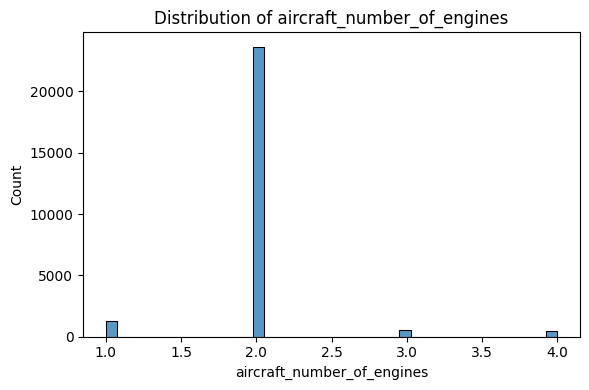

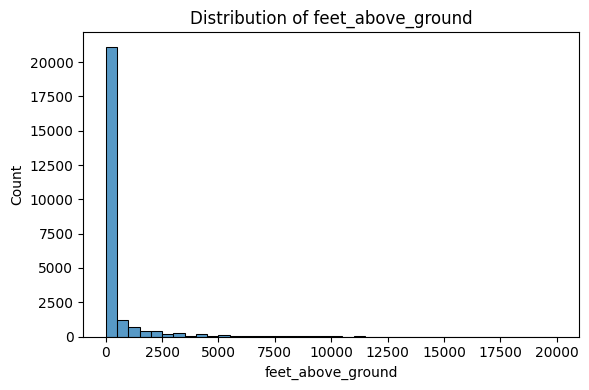

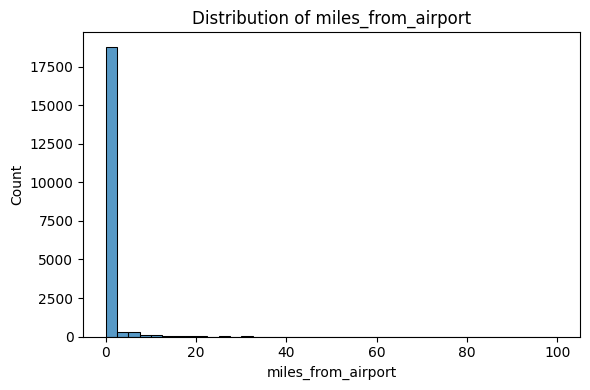

In [166]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=40)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [167]:
# Numeric Variables vs Damage

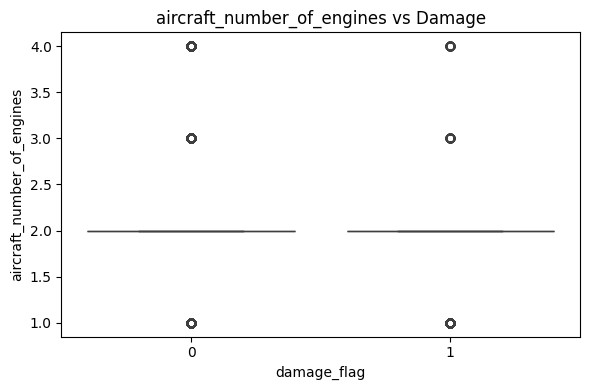

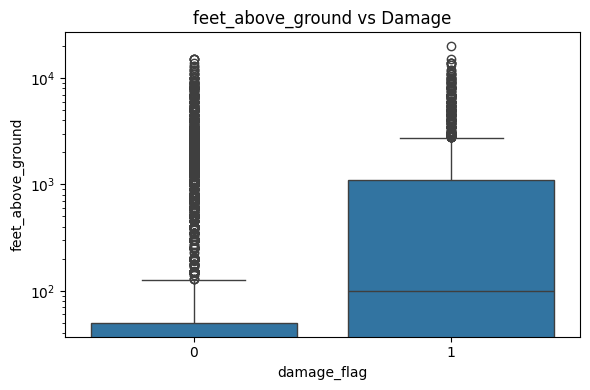

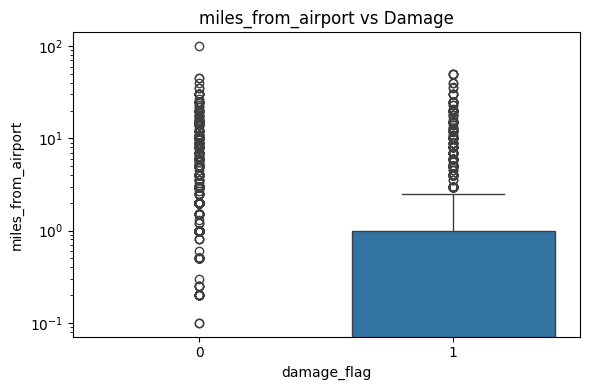

In [168]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="damage_flag", y=col)
    plt.title(f"{col} vs Damage")
    
    if col in ["feet_above_ground", "miles_from_airport"]:
        plt.yscale("log")
    
    plt.tight_layout()
    plt.show()

In [169]:
# Categorical Variables

In [170]:
# Damage Rate by Categorical Variables

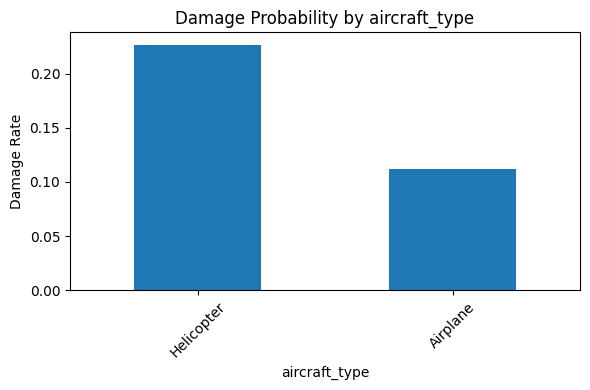

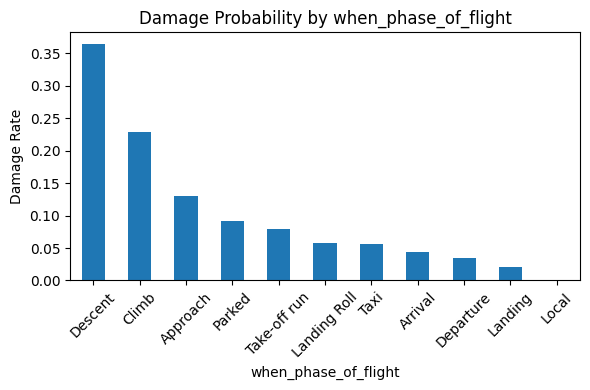

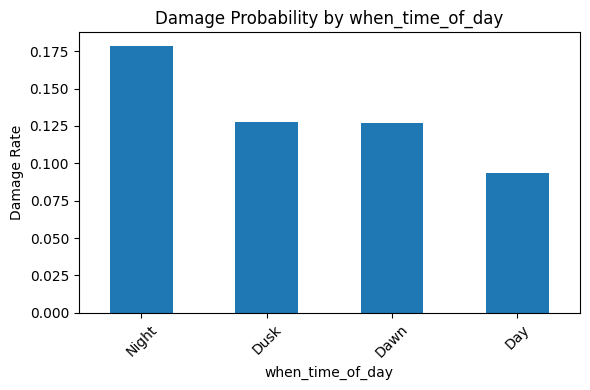

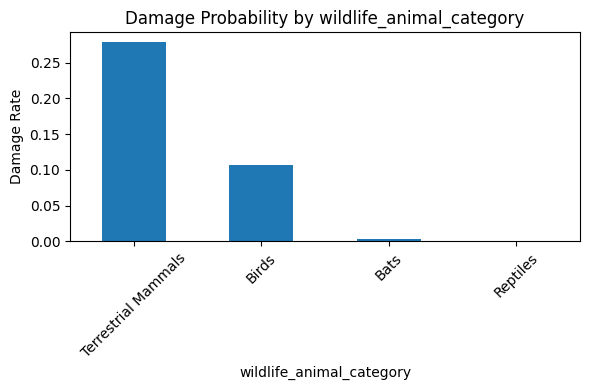

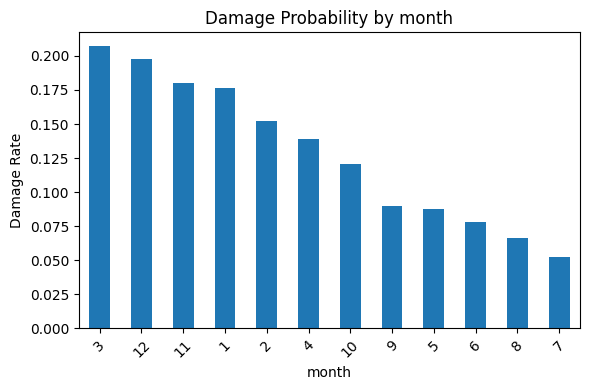

In [171]:
cat_cols = [
    "aircraft_type",
    "when_phase_of_flight",
    "when_time_of_day",
    "wildlife_animal_category",
    "month"
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    
    damage_rates = (
        df.groupby(col)["damage_flag"]
          .mean()
          .sort_values(ascending=False)
    )
    
    damage_rates.plot(kind="bar")
    plt.title(f"Damage Probability by {col}")
    plt.ylabel("Damage Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [172]:
# Phase of Flight — Stacked Percentage Plot

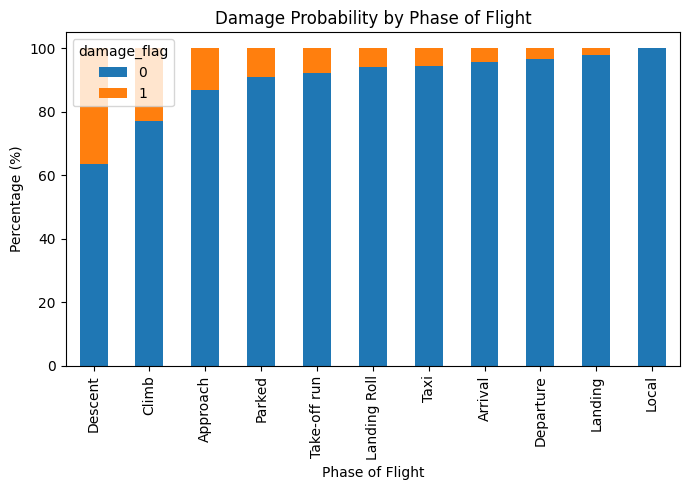

In [173]:
phase_damage = (
    pd.crosstab(
        df["when_phase_of_flight"],
        df["damage_flag"],
        normalize="index"
    ) * 100
)

phase_damage = phase_damage.sort_values(by=1, ascending=False)

ax = phase_damage.plot(kind="bar", stacked=True, figsize=(7,5))
ax.set_title("Damage Probability by Phase of Flight")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Phase of Flight")
plt.tight_layout()
plt.show()

In [174]:
# Correlation Check (Numeric Only)

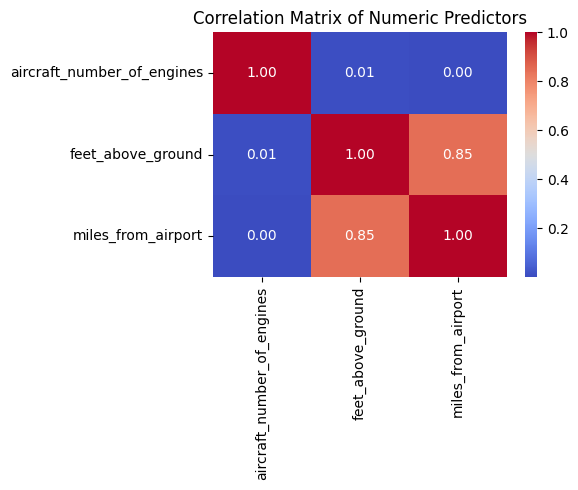

In [175]:
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Predictors")
plt.tight_layout()
plt.show()

In [176]:
df.columns.tolist()

['aircraft_type',
 'aircraft_number_of_engines',
 'collision_date_and_time',
 'when_time_of_day',
 'when_phase_of_flight',
 'effect_indicated_damage',
 'feet_above_ground',
 'miles_from_airport',
 'wildlife_animal_category',
 'damage_flag',
 'month']

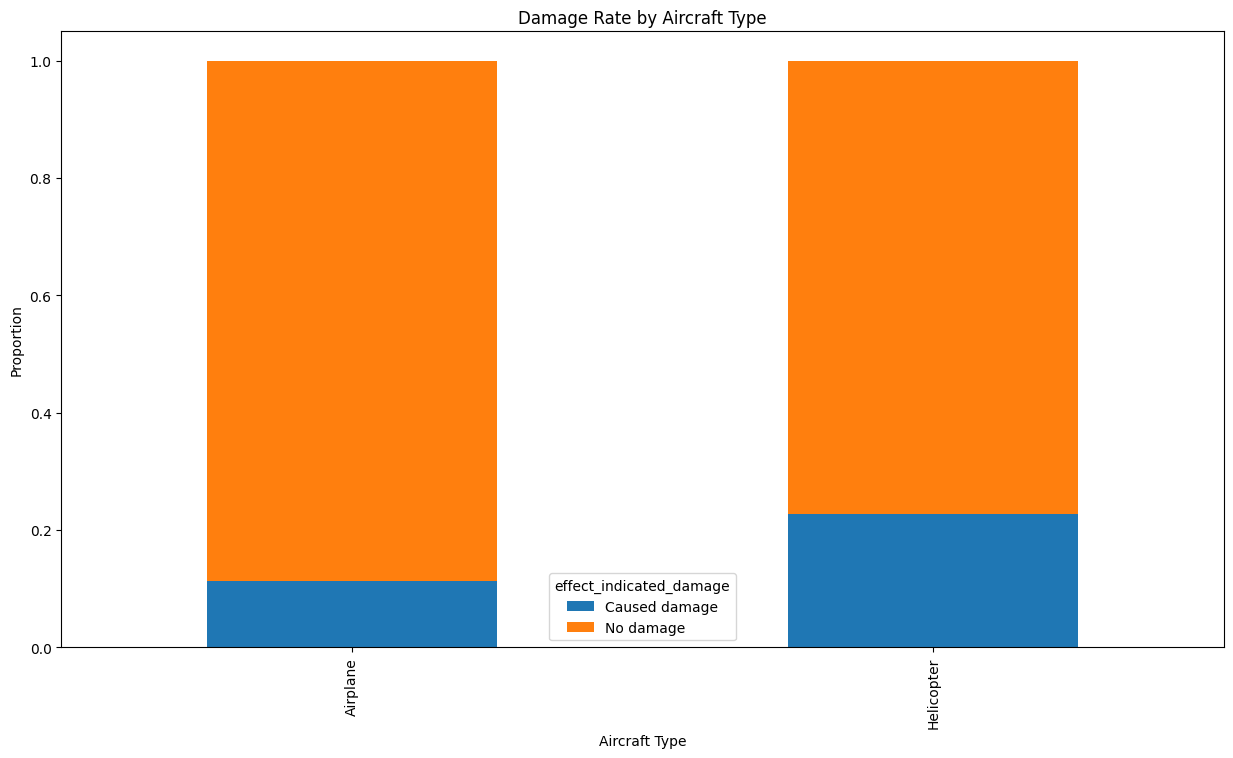

In [177]:
# Aircraft type vs damage
pd.crosstab(
    df['aircraft_type'],
    df['effect_indicated_damage'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title("Damage Rate by Aircraft Type")
plt.ylabel("Proportion")
plt.xlabel("Aircraft Type")
plt.show()

Category: Operational factor

A normalized cross-tabulation between aircraft type and indicated damage was plotted using a stacked bar chart, showing the proportion of damage outcomes within each aircraft category. This approach allows comparison of damage likelihood conditional on aircraft type rather than raw incident counts. The results indicate that airplanes experience a lower proportion of damage outcomes, whereas helicopters show a relatively higher damage rate during wildlife strikes. This suggests aircraft design and operational characteristics may influence strike severity. These findings provide preliminary evidence supporting the role of operational factors in wildlife strike damage risk.

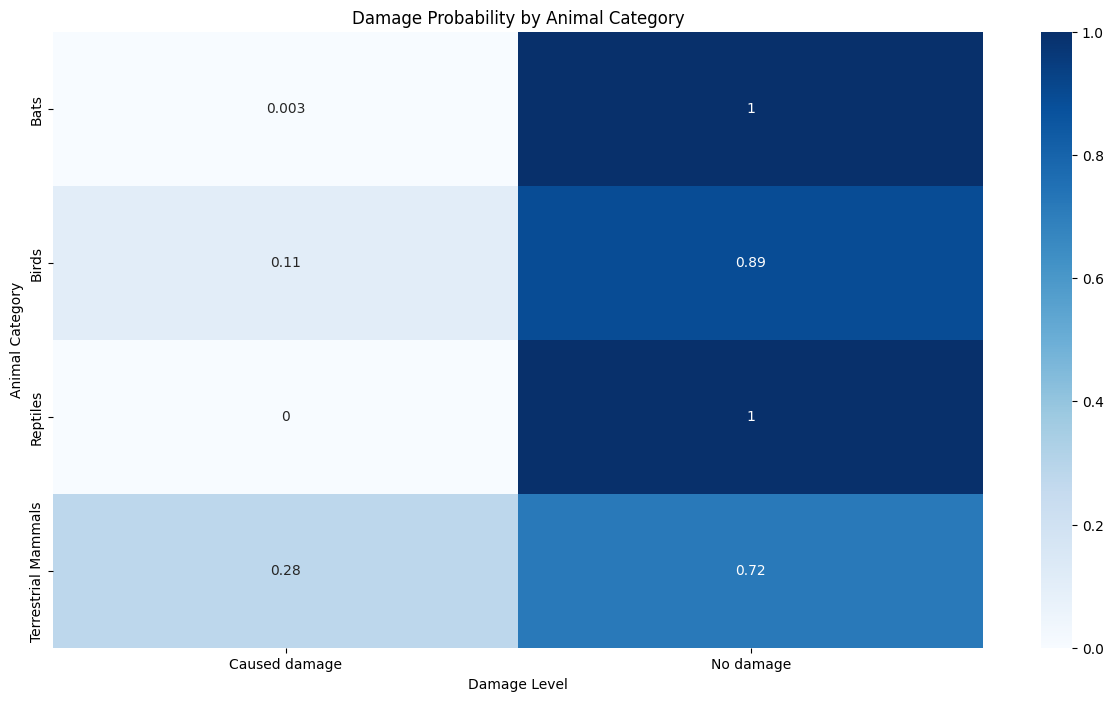

In [178]:
# Damage Probability by Animal Category
ct = pd.crosstab(
    df['wildlife_animal_category'],
    df['effect_indicated_damage'],
    normalize='index'
)

sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Damage Probability by Animal Category")
plt.xlabel("Damage Level")
plt.ylabel("Animal Category")
plt.show()

Category: Environmental factor

This plot shows the relationship between wildlife animal category and whether a strike caused damage. A normalized cross-tab was used and visualized as a heatmap, meaning each row represents the probability of damage within that animal category. The results indicate that terrestrial mammals have the highest likelihood of causing damage, birds show moderate damage probability, while bats and reptiles rarely lead to damage. This suggests that the type of wildlife involved is an important environmental factor influencing strike severity. These insights help explain differences in damage risk across wildlife categories.

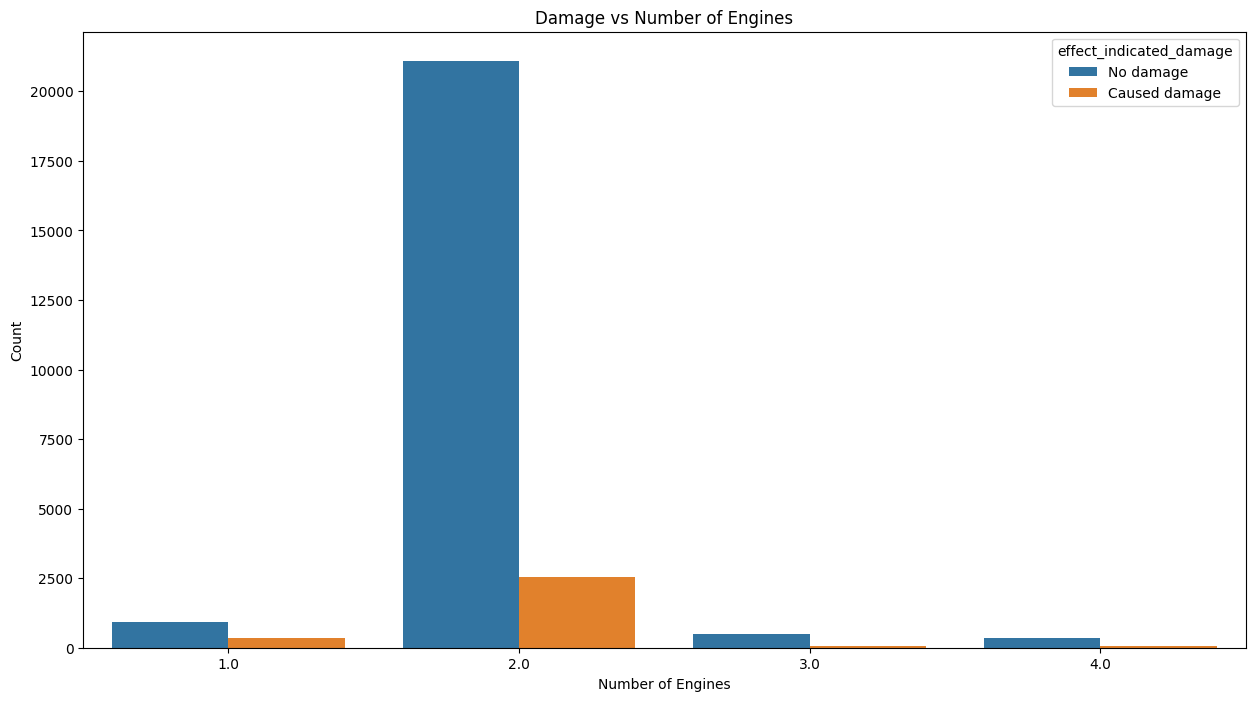

In [179]:
# Number of engines vs damage
sns.countplot(
    data=df,
    x='aircraft_number_of_engines',
    hue='effect_indicated_damage'
)

plt.title("Damage vs Number of Engines")
plt.xlabel("Number of Engines")
plt.ylabel("Count")
plt.show()

Category: Operational factor

This plot examines how the number of aircraft engines relates to damage occurrence during wildlife strikes. A count plot was used to compare the frequency of damage vs no damage across different engine counts. The results show that most incidents involve aircraft with two engines, which is expected due to their higher presence in the dataset, but damage still occurs across all engine categories. Aircraft with fewer engines appear to have a slightly higher proportion of damage cases, suggesting engine configuration may influence vulnerability. Overall, the number of engines is a relevant operational characteristic contributing to damage risk.

In [180]:
# Checking null values again

In [181]:
df.isnull().sum()/len(df)*100

aircraft_type                  2.936603
aircraft_number_of_engines     8.410488
collision_date_and_time        0.000000
when_time_of_day               2.272245
when_phase_of_flight           1.434730
effect_indicated_damage        0.000000
feet_above_ground             12.106863
miles_from_airport            30.005654
wildlife_animal_category       0.000000
damage_flag                    0.000000
month                          0.000000
dtype: float64

In [182]:
# Dropping the null values

In [183]:
model_vars = [
    "damage_flag",
    "aircraft_type",
    "aircraft_number_of_engines",
    "when_phase_of_flight",
    "when_time_of_day",
    "feet_above_ground",
    "miles_from_airport",
    "wildlife_animal_category",
    "month"
]

model_df = df[model_vars].dropna()

print("Original shape:", df.shape)
print("Model shape after dropping NA:", model_df.shape)

Original shape: (28298, 11)
Model shape after dropping NA: (17670, 9)


In [184]:
# Comparing the damage proportion before and after dropping the null values

In [185]:
print("Original damage rate:", df["damage_flag"].mean())
print("Model damage rate:", model_df["damage_flag"].mean())

Original damage rate: 0.10993709802812919
Model damage rate: 0.09388794567062818


In [186]:
model_df

,damage_flag,aircraft_type,aircraft_number_of_engines,when_phase_of_flight,when_time_of_day,feet_above_ground,miles_from_airport,wildlife_animal_category,month
2,1,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,4
5,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,3
6,0,Airplane,3.0,Take-off run,Day,0.0,0.0,Birds,4
11,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,8
12,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,6
...,...,...,...,...,...,...,...,...,...
28276,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,7
28277,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,5
28278,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,7
28282,0,Airplane,2.0,Landing Roll,Dusk,0.0,0.0,Birds,9


In [187]:
# No null value is remaining

In [188]:
model_df.isnull().sum()

damage_flag                   0
aircraft_type                 0
aircraft_number_of_engines    0
when_phase_of_flight          0
when_time_of_day              0
feet_above_ground             0
miles_from_airport            0
wildlife_animal_category      0
month                         0
dtype: int64

In [189]:
model_df

,damage_flag,aircraft_type,aircraft_number_of_engines,when_phase_of_flight,when_time_of_day,feet_above_ground,miles_from_airport,wildlife_animal_category,month
2,1,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,4
5,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,3
6,0,Airplane,3.0,Take-off run,Day,0.0,0.0,Birds,4
11,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,8
12,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,6
...,...,...,...,...,...,...,...,...,...
28276,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,7
28277,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,5
28278,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,7
28282,0,Airplane,2.0,Landing Roll,Dusk,0.0,0.0,Birds,9


In [190]:

# Chi-square test function for categorical variables
def chi_square_test(df, col, target='damage_flag'):
    
    ct = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    print(f"\nChi-square test for: {col} vs {target}")
    print(f"Chi2: {chi2:.4f}")
    
    if p < 0.001:
        print("p-value: < 0.001")
    else:
        print(f"p-value: {p:.4f}")
        
    print("Degrees of freedom:", dof)
    
    if p < 0.05:
        print("Result: Significant association")
    else:
        print("Result: No significant association")
        
    return ct

In [191]:
chi_square_test(model_df, 'aircraft_type')
chi_square_test(model_df, 'when_phase_of_flight')
chi_square_test(model_df, 'when_time_of_day')
chi_square_test(model_df, 'wildlife_animal_category')



Chi-square test for: aircraft_type vs damage_flag
Chi2: 4.2365
p-value: 0.0396
Degrees of freedom: 1
Result: Significant association

Chi-square test for: when_phase_of_flight vs damage_flag
Chi2: 506.0512
p-value: < 0.001
Degrees of freedom: 8
Result: Significant association

Chi-square test for: when_time_of_day vs damage_flag
Chi2: 271.9696
p-value: < 0.001
Degrees of freedom: 3
Result: Significant association

Chi-square test for: wildlife_animal_category vs damage_flag
Chi2: 374.2226
p-value: < 0.001
Degrees of freedom: 3
Result: Significant association


damage_flag,0,1
wildlife_animal_category,,
Bats,110,0
Birds,15358,1444
Reptiles,30,0
Terrestrial Mammals,513,215


Chi-square tests were conducted to assess the association between categorical predictors and wildlife strike damage.

• Aircraft type (operational factor): p = 0.0396 → significant association; damage likelihood differs across aircraft types

• Phase of flight (operational factor): p < 0.001 → strong association; flight stage significantly affects damage risk

• Time of day (environmental factor): p < 0.001 → strong association; wildlife activity and visibility influence damage occurrence

• Wildlife animal category (environmental factor): p < 0.001 → strong association; different animal groups pose different damage risks

Contingency table insights:
• Birds account for most strike events overall

• Terrestrial mammals show a higher proportion of damage relative to incidents

• Bats and reptiles rarely cause damage

Overall, both operational and environmental categorical factors are significantly associated with wildlife strike damage.

In [192]:
# T-test function for numeric variables

def t_test_numeric(df, numeric_col, target='damage_flag'):
    
    group0 = df[df[target] == 0][numeric_col].dropna()
    group1 = df[df[target] == 1][numeric_col].dropna()
    
    t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
    
    print(f"\nT-test for: {numeric_col} vs {target}")
    print(f"T-statistic: {t_stat:.4f}")
    
    if p_val < 0.001:
        print("p-value: < 0.001")
    else:
        print(f"p-value: {p_val:.4f}")
        
    if p_val < 0.05:
        print("Result: Significant difference between groups")
    else:
        print("Result: No significant difference")

In [193]:
t_test_numeric(model_df, 'feet_above_ground')
t_test_numeric(model_df, 'miles_from_airport')
t_test_numeric(model_df, 'aircraft_number_of_engines')


T-test for: feet_above_ground vs damage_flag
T-statistic: -13.8566
p-value: < 0.001
Result: Significant difference between groups

T-test for: miles_from_airport vs damage_flag
T-statistic: -12.3982
p-value: < 0.001
Result: Significant difference between groups

T-test for: aircraft_number_of_engines vs damage_flag
T-statistic: 5.2835
p-value: < 0.001
Result: Significant difference between groups


T-tests were conducted to examine whether numeric predictors differ between damage and no-damage groups.

• **Feet above ground (operational factor):** p < 0.001 → significant difference; altitude levels differ between damage and non-damage incidents

• **Miles from airport (operational factor):** p < 0.001 → significant difference; distance from airport is associated with damage occurrence

• **Aircraft number of engines (operational factor):** p < 0.001 → significant difference; aircraft engine configuration influences damage risk

Overall, the results indicate that key operational numeric variables show statistically significant differences between damage and no-damage wildlife strike events.


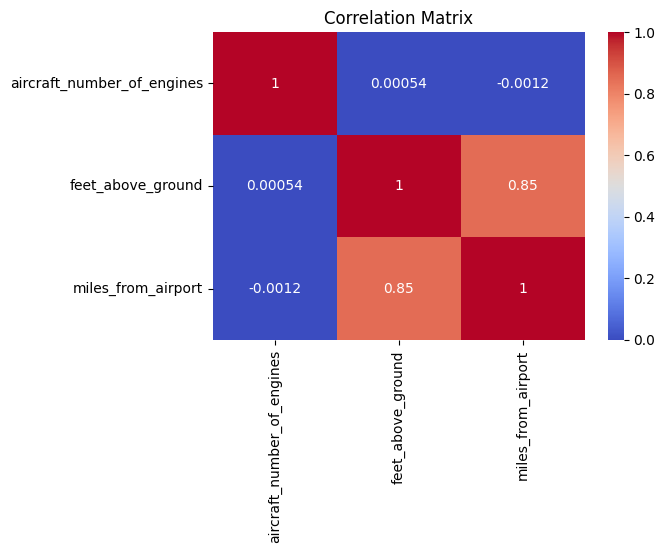

In [194]:
# Correlation Matrix for numeric variables

numeric_cols = [
    'aircraft_number_of_engines',
    'feet_above_ground',
    'miles_from_airport'
]

corr = model_df[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Correlation analysis was performed to examine relationships among numeric operational predictors.

• **Aircraft number of engines vs other variables:** near zero correlation → engine configuration is largely independent of altitude and distance

• **Feet above ground vs miles from airport:** strong positive correlation (≈ 0.85) → altitude increases as aircraft move farther from the airport

• **Miles from airport vs engines:** negligible negative correlation → no meaningful relationship

Overall, the results indicate potential multicollinearity between altitude and distance from airport, while number of engines remains an independent predictor.


In [195]:
#GLM Model Building

model_encoded = pd.get_dummies(model_df, drop_first=True)
model_encoded = model_encoded.apply(pd.to_numeric, errors="coerce").dropna()

X = model_encoded.drop(columns=["damage_flag"]).astype(float)
y = model_encoded["damage_flag"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

glm_model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
print(glm_model.summary())

odds_ratios = pd.DataFrame({
    "Variable": glm_model.params.index,
    "Odds Ratio": np.exp(glm_model.params)
})

def format_or(x):
    if x < 0.001:
        return "<0.001"
    elif x > 1000:
        return ">1000"
    else:
        return f"{x:.4f}"

odds_ratios["Odds Ratio"] = odds_ratios["Odds Ratio"].apply(format_or)
print(odds_ratios)

pred_prob = glm_model.predict(X_test)
pred = (pred_prob > 0.25).astype(int)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

fpr, tpr, _ = roc_curve(y_test, pred_prob)
auc = roc_auc_score(y_test, pred_prob)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            damage_flag   No. Observations:                14136
Model:                            GLM   Df Residuals:                    14118
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3974.6
Date:                Sat, 28 Feb 2026   Deviance:                       7949.3
Time:                        08:54:35   Pearson chi2:                 1.39e+04
No. Iterations:                    23   Pseudo R-squ. (CS):            0.05869
Covariance Type:            nonrobust                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

**GLM logistic regression -- purpose & process**

• A GLM logistic regression was developed to estimate the probability of **damage_flag = 1** using selected operational and environmental predictors.

• Categorical variables were one-hot encoded to enable regression modelling, and missing observations were removed to ensure numeric consistency.

• A train–test split was applied so the model was fitted on training data and evaluated on unseen test data.

• Model coefficients represent changes in log-odds of damage, while odds ratios provide interpretable risk effects.

• Performance was assessed using confusion matrix, classification metrics, ROC curve, and AUC.



**Key results from coefficients / odds ratios**

• Aircraft number of engines (OR ≈ 0.64, p < 0.001) → more engines are associated with lower damage probability.

• Feet above ground (OR ≈ 1.0003, p < 0.001) → altitude shows a small but significant positive effect on damage risk.

• Miles from airport (p ≈ 0.14) and **month (p ≈ 0.33)** → no significant effect.

• **Phase of flight (operational factor)**
   Climb increases damage risk (OR ≈ 1.68, p < 0.001)

   Landing roll, taxi, and take-off run reduce risk (OR < 1, significant)
   
   Some phase levels show unstable estimates due to sparse data

• **Time of day (environmental factor)**
– Day reduces damage risk (OR ≈ 0.65, p = 0.005)

– Dusk and night are not significant

• **Wildlife animal category** shows extremely large OR values for some groups, indicating quasi-separation caused by rare damage observations.



**Model performance**

• Accuracy ≈ **0.89** on test data → good overall classification of non-damage events.

• Damage precision ≈ **0.33** and recall ≈ **0.21** → improved detection compared to earlier model but still limited due to imbalance.

• ROC-AUC ≈ **0.72** → moderate discrimination between damage and no-damage strikes.

• Confusion matrix confirms strong non-damage prediction but continued difficulty capturing rare damage cases.



**Overall insights**

• Operational variables, particularly flight phase and aircraft configuration, are the most influential predictors of damage risk.

• Altitude contributes positively to damage probability, reflecting exposure patterns during flight.

• Environmental timing variables (month, dusk/night) show limited explanatory power in this dataset.

• Wildlife category effects are unstable because damage cases are sparse for some animal groups.

• The model provides meaningful explanatory insight but predictive performance for damage remains constrained by class imbalance, 
suggesting further improvement through threshold tuning or imbalance-handling techniques.


In [196]:
glm_model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()

print(glm_model.summary())
print("AIC:", glm_model.aic)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            damage_flag   No. Observations:                14136
Model:                            GLM   Df Residuals:                    14118
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3974.6
Date:                Sat, 28 Feb 2026   Deviance:                       7949.3
Time:                        08:54:35   Pearson chi2:                 1.39e+04
No. Iterations:                    23   Pseudo R-squ. (CS):            0.05869
Covariance Type:            nonrobust                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

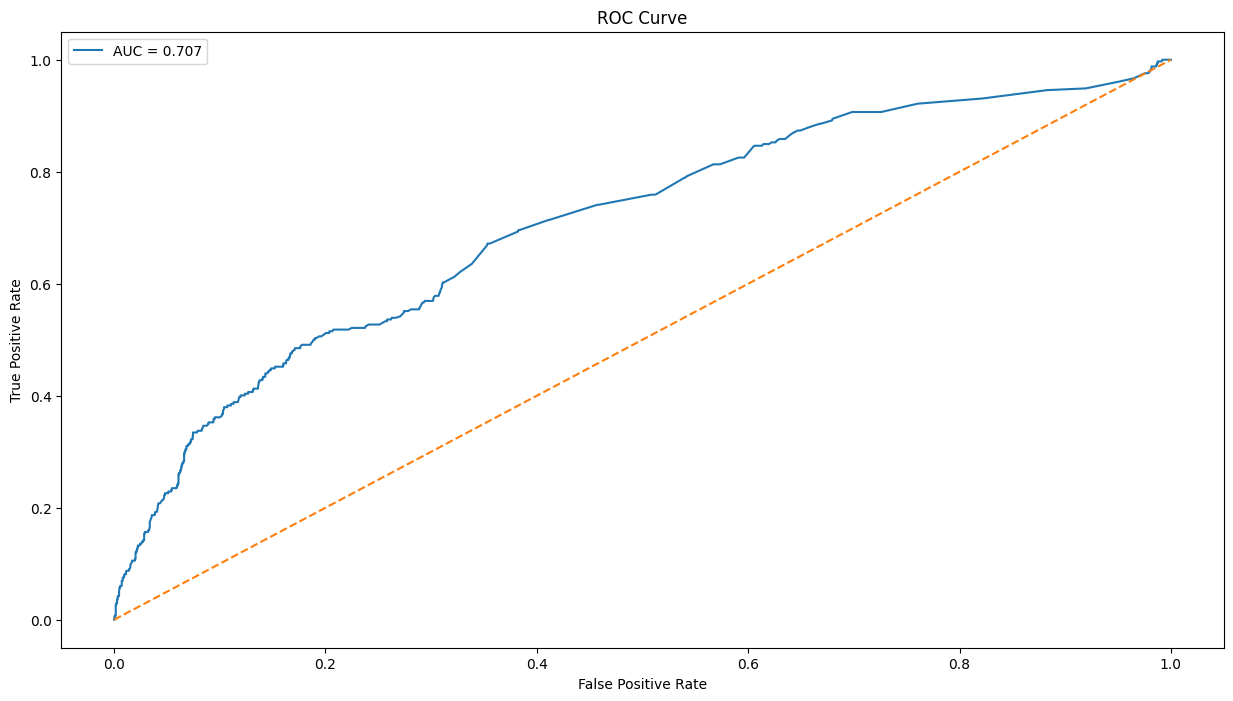

In [197]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**ROC curve interpretation and insight**

• The ROC curve evaluates how well the model distinguishes between damage and no-damage events on **unseen test data** across different probability thresholds.

• The curve remains above the random baseline, indicating the model captures meaningful patterns related to wildlife strike damage.

• **AUC = 0.707** shows **moderate predictive ability** - slightly lower than before due to train–test split, but more reliable and realistic.

• The model can rank higher-risk strikes reasonably well, yet it still struggles to identify many true damage cases.

• This behaviour is consistent with the confusion matrix, where non-damage is predicted accurately while damage recall remains low because of class imbalance.

**Insight:**
The model provides useful discrimination but requires threshold tuning or imbalance handling to improve damage detection performance.


In [198]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [199]:
X = model_df.drop(columns=['damage_flag'])
y = model_df['damage_flag']

print(f"Dataset shape : {X.shape}")
print(f"Damage rate   : {y.mean()*100:.1f}% caused damage\n")

Dataset shape : (17670, 8)
Damage rate   : 9.4% caused damage



                                     Feature  Importance
                           feet_above_ground    0.315568
                                       month    0.248378
                          miles_from_airport    0.180187
                  aircraft_number_of_engines    0.080556
wildlife_animal_category_Terrestrial Mammals    0.031461
                  when_phase_of_flight_Climb    0.024969
                      when_time_of_day_Night    0.024252
              wildlife_animal_category_Birds    0.023692
                        when_time_of_day_Day    0.020434
           when_phase_of_flight_Landing Roll    0.013276
                when_phase_of_flight_Descent    0.010863
                       when_time_of_day_Dusk    0.010557
           when_phase_of_flight_Take-off run    0.008043
                    aircraft_type_Helicopter    0.003104
                   when_phase_of_flight_Taxi    0.002658


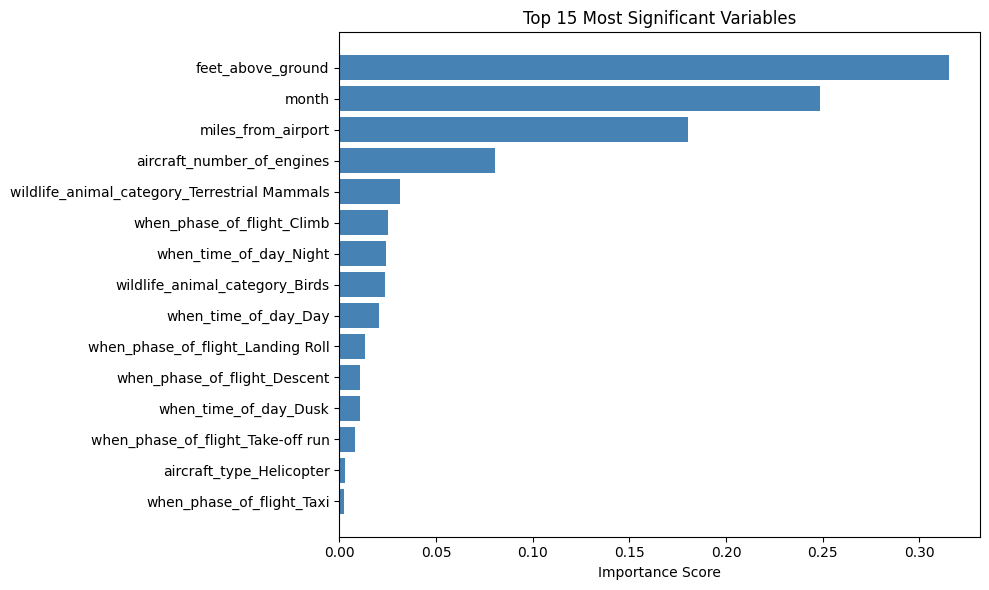

In [200]:
# Features Importance

# Convert any remaining categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

rf_check = RandomForestClassifier(n_estimators=100, random_state=42)
rf_check.fit(X, y)

feat_df = (pd.DataFrame({'Feature': X.columns,
                         'Importance': rf_check.feature_importances_})
           .sort_values('Importance', ascending=False)
           .head(15)
           .reset_index(drop=True))

print(feat_df.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Top 15 Most Significant Variables")
plt.tight_layout()
plt.show()

In [201]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [202]:
#Train models and compare

MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []

for name, model in MODELS.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model':         name,
        'CV Accuracy':   round(cv_scores.mean(), 4),
        'CV Std':        round(cv_scores.std(), 4),
        'Test Accuracy': round(test_acc, 4)
    })

    print(f"\n-- {name} --")
    print(f"   CV Accuracy  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(classification_report(y_test, y_pred,
                                target_names=['No Damage', 'Caused Damage']))



-- Logistic Regression --
   CV Accuracy  : 0.9058 +/- 0.0019
   Test Accuracy: 0.9061
               precision    recall  f1-score   support

    No Damage       0.91      1.00      0.95      3202
Caused Damage       0.50      0.04      0.07       332

     accuracy                           0.91      3534
    macro avg       0.70      0.52      0.51      3534
 weighted avg       0.87      0.91      0.87      3534


-- Decision Tree --
   CV Accuracy  : 0.9080 +/- 0.0009
   Test Accuracy: 0.9072
               precision    recall  f1-score   support

    No Damage       0.91      0.99      0.95      3202
Caused Damage       0.53      0.11      0.18       332

     accuracy                           0.91      3534
    macro avg       0.72      0.55      0.56      3534
 weighted avg       0.88      0.91      0.88      3534


-- Random Forest --
   CV Accuracy  : 0.9046 +/- 0.0024
   Test Accuracy: 0.9001
               precision    recall  f1-score   support

    No Damage       0.91  

In [203]:
# GLM accuracy
glm_preds = (pred_prob > 0.25).astype(int)
glm_acc   = accuracy_score(y_test, glm_preds)

print(f"\n-- GLM --")
print(f"   Test Accuracy: {glm_acc:.4f}")
print(classification_report(y_test, glm_preds,
                            target_names=['No Damage', 'Caused Damage']))

# Add to results
results.append({
    'Model':         'GLM',
    'CV Accuracy':   'N/A',
    'CV Std':        'N/A',
    'Test Accuracy': round(glm_acc, 4)
})


-- GLM --
   Test Accuracy: 0.8868
               precision    recall  f1-score   support

    No Damage       0.92      0.96      0.94      3202
Caused Damage       0.33      0.21      0.26       332

     accuracy                           0.89      3534
    macro avg       0.63      0.58      0.60      3534
 weighted avg       0.87      0.89      0.87      3534



SUMMARY TABLE
              Model CV Accuracy  CV Std  Test Accuracy
      Decision Tree       0.908  0.0009         0.9072
Logistic Regression      0.9058  0.0019         0.9061
      Random Forest      0.9046  0.0024         0.9001
                GLM         N/A     N/A         0.8868

Best Model    : Decision Tree
Test Accuracy : 0.9072 (90.7%)


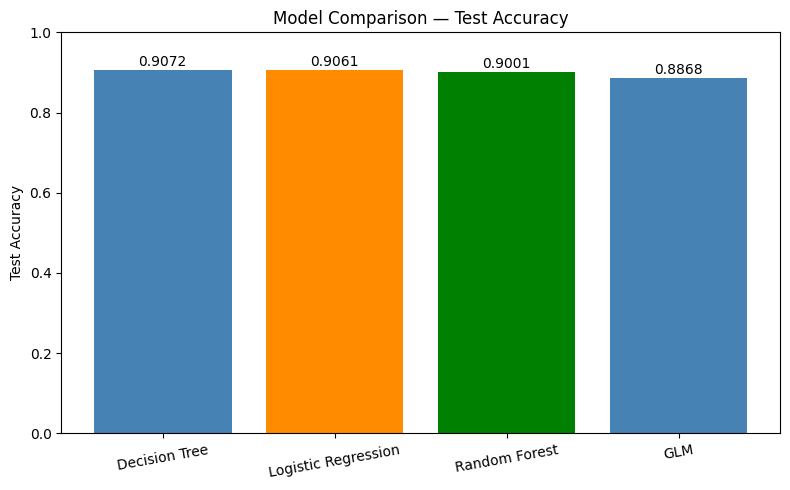

In [204]:
#Comparison

print("=" * 55)
print("SUMMARY TABLE")
print("=" * 55)
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

best_model = results_df.iloc[0]['Model']
best_acc   = results_df.iloc[0]['Test Accuracy']
print(f"\nBest Model    : {best_model}")
print(f"Test Accuracy : {best_acc:.4f} ({best_acc*100:.1f}%)")

# Bar chart comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['Test Accuracy'],
        color=['steelblue', 'darkorange', 'green'])
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison — Test Accuracy")
plt.xticks(rotation=10)
for i, row in results_df.iterrows():
    plt.text(i, row['Test Accuracy'] + 0.01,
             f"{row['Test Accuracy']:.4f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()